In [15]:
from typing import Dict, List, Any, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END

# ============================================================
# State Definition
# ============================================================
class AgentState(TypedDict):
    messages: Sequence[BaseMessage]
    question: str               # Original user question
    standalone_question: str    # Reformulated question (context-aware)
    documents: List[Any]
    generation: str
    citations: List[Dict[str, Any]]
    iterations: int
    grade: str
    feedback: str


# ============================================================
# Graph Workflow Builder
# ============================================================
def build_pdf_agent_graph(
    reformulate_node,
    retrieve_node,
    generate_node,
    reflect_node,
):
    """
    Build and compile the LangGraph workflow for the PDF agent.

    Parameters expect callables with signature: (state: AgentState) -> AgentState
    that implement:
      - reformulate_node: reformulate_query
      - retrieve_node: retrieve_documents
      - generate_node: generate_answer
      - reflect_node: reflect_and_improve_answer
    """
    workflow = StateGraph(AgentState)

    # Register nodes
    workflow.add_node("reformulate", reformulate_node)
    workflow.add_node("retrieve", retrieve_node)
    workflow.add_node("generate", generate_node)
    workflow.add_node("reflect", reflect_node)

    # Linear flow: START -> reformulate -> retrieve -> generate -> reflect
    workflow.add_edge(START, "reformulate")
    workflow.add_edge("reformulate", "retrieve")
    workflow.add_edge("retrieve", "generate")
    workflow.add_edge("generate", "reflect")

    # Reflection decides whether to stop or re-generate
    workflow.add_conditional_edges(
        "reflect",
        # this should be a function like: decide_to_generate(state) -> Literal["useful", "not_useful"]
        lambda state: state["grade"],  # placeholder, replace with your decide_to_generate function
        {"useful": END, "not_useful": "generate"},
    )

    return workflow.compile()

In [16]:
def reformulate_node(state: AgentState) -> AgentState:
    # TODO: replace with real implementation
    return state


def retrieve_node(state: AgentState) -> AgentState:
    # TODO: replace with real implementation
    return state


def generate_node(state: AgentState) -> AgentState:
    # TODO: replace with real implementation
    return state


def reflect_node(state: AgentState) -> AgentState:
    # TODO: replace with real implementation
    return state


In [17]:
graph = build_pdf_agent_graph(
    reformulate_node=reformulate_node,
    retrieve_node=retrieve_node,
    generate_node=generate_node,
    reflect_node=reflect_node,
)

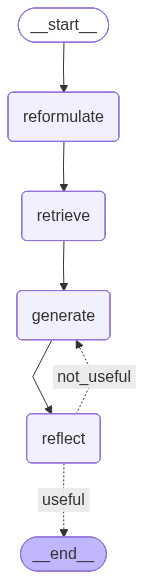

In [18]:
graph